## 1.2 Classification.    
Classification is a type of supervised machine learning where the goal is to predict a categorical label (class) for a given input based on previously labeled training data.  
Instead of predicting a continuous numerical value (like house price or salary), classification predicts which category an observation belongs to.   

__Types of classification__    
1. Binary Classification: Predicts one of two possible classes. e.g email filtering i.e predicting if an email is spam or not spam.    
2. Multi-class classification: The model predicts one class out of three or more categories. e.g animal classification.  
3. Multi-Label Classification: An observation can belong to multiple classes simultaneously.     

_Popular classification algorithms_     
- Logistic regression. 
- K-Nearest Neighbour 
- Decision Tree.   
- Random forest. 
- Gradient Boosting.     
- Support Vector Machine(SVM)
- Naive Bayes   

### Evaluation Metrics in Classification.   
#### a). Confusion Matrix
It is a simple table that compares what the model predicted against what actually happened.

|                  |Predicted Positive|Predicted Negative|
|------------------|------------------|------------------|
|Actual Positive   |True Positive(TP) |False Negative(FN)|
|Actual Negative   |False Positive(FP)| True Negative(TN)|     

__The four possible outcomes__  
- True Positive (TP): the model predicted positive and it was actually positive
- True Negative (TN): the model predicted negative and it was actually negative
- False Positive (FP): the model predicted positive but it was actually negative (a false alarm)
- False Negative (FN): the model predicted negative but it was actually positive (a miss)

#### b). Accuracy 
Accuracy tells you the percentage of predictions the model got right, out of all predictions made.  

_Formula_   
${Accuracy} = \frac{{TP} + {TN}}{{TP} + {TN} + {FP} + {FN}}$    

Accuracy is easy to understand, but it can be misleading when the classes are imbalanced. For example, if 95 percent of emails are not spam, a model that always predicts not spam will have 95 percent accuracy without being useful at all.  

_Use when_  
Your classes are roughly balanced and every type of mistake costs about the same.  

_Avoid it when_    
Your classes are imbalanced, or false positives and false negatives have very different costs.    

#### c). Precision    
Precision answers the question: of everything the model labeled as positive, how many were actually positive?   

_Formula_    

$Precision = \frac{TP}{TP + FP}$     

High precision means the model does not raise many false alarms. This matters when the cost of a false positive is high, for example flagging a genuine transaction as fraud.  

_Use it when_ False positives are costly or disruptive, such as marking a good transaction as fraud or a real email as spam.   

_Avoid it when_ Missing a positive case is far more costly than a false alarm, since precision on its own ignores false negatives.     

#### d). Recall   
Recall answers the question: of all the actual positives, how many did the model correctly find?    
_Formula_    

$Recall = \frac{TP}{TP + FN}$

High recall means the model rarely misses a true positive. This matters when missing a positive case is costly, for example failing to detect a disease.  

_Use it when_ Missing a positive case is dangerous or expensive, such as in medical screening or security threat detection.    

_Avoid it when_ False alarms are costly and need to stay low, since recall on its own ignores false positives.    

#### e). F1-Score     
Precision and recall often trade off against each other. The F1 Score combines both into a single number using their harmonic mean, so it is useful when you want one balanced measure.    

_Formula_    
$F1 = {2} * \frac{Precision * Recall}{(Precision + Recall)}$  

The F1 Score is especially helpful when the classes are imbalanced and accuracy alone is not trustworthy.   

_Use it when_ You need one single score that balances precision and recall, especially with imbalanced classes.   

_Avoid it when_ You care a lot more about one of precision or recall specifically, since F1 hides that difference by averaging them.  

### 1.2.1 Logistic regression.    
Logistic Regression is a supervised learning algorithm used for predicting categorical outcomes by estimating probabilities.     
Logistic regression calculates the probability (p) that a given data point belongs to a specific class. It does this by passing a linear equation through the sigmoid function, compressing the output to a value between 0 and 1.    

_Formula_   
$p = \sigma(z) = \frac{1}{1 + e^{-z}}$    

Where:   
- \(p\) is the predicted probability of the outcome being 1 (e.g., "True" or "Success").   
- $e$ is Euler's number (approximately 2.718)
- z is the standard linear regression equation.    

![Logistic regression](https://zd-brightspot.s3.us-east-1.amazonaws.com/wp-content/uploads/2022/04/11040521/46-4-e1715636469361.png)    


### Financial inclusion Project    
__STEP 1: Load the dataset and the relevant libraries__ 

In [2]:
# Load the relevant libraries
import pandas as pd

In [3]:
# Load the dataset
finance_data = pd.read_csv(r'D:\LuxDev Curriculum\Machine-learning-notes\Supervised_Learning\Classification\data\financial_inclusion.csv')

finance_data.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


__STEP 2: Basic Data Exploration__

In [6]:
def basic_checks(df):
    """
    Perform basic checks on the dataframe.
    
    Parameters:
    df (pd.DataFrame): The dataframe to check.
    
    Returns:
    None
    """
    # Check for missing values
    print("-" * 40, "MISSING VALUES", "-" * 40)
    print(df.isnull().sum())

    # Check for duplicates
    print("-" * 40, "DUPLICATES", "-" * 40)
    print(df.duplicated().sum())

    # Check data types
    print("-" * 40, "DATA TYPES", "-" * 40)
    print(df.dtypes)

    # Summary statistics for numerical columns
    print("-" * 40, "SUMMARY STATISTICS", "-" * 40)
    print(display(df.describe().T))

    # Summary statistics for categorical columns
    print("-" * 40, "CATEGORICAL SUMMARY", "-" * 40)
    print(display(df.describe(include='str').T))

    # Check for unique values in each column
    print("-" * 40, "UNIQUE VALUES", "-" * 40)


basic_checks(finance_data)

---------------------------------------- MISSING VALUES ----------------------------------------
country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64
---------------------------------------- DUPLICATES ----------------------------------------
0
---------------------------------------- DATA TYPES ----------------------------------------
country                     str
year                      int64
uniqueid                    str
bank_account                str
location_type               str
cellphone_access            str
household_size            int64
age_of_respondent         int64
gender_of_respondent        str
relationship_with_head      str
marital_status    

,count,mean,std,min,25%,50%,75%,max
year,23524.0,2016.975939,0.847371,2016.0,2016.0,2017.0,2018.0,2018.0
household_size,23524.0,3.797483,2.227613,1.0,2.0,3.0,5.0,21.0
age_of_respondent,23524.0,38.805220,16.520569,16.0,26.0,35.0,49.0,100.0


None
---------------------------------------- CATEGORICAL SUMMARY ----------------------------------------


,count,unique,top,freq
country,23524,4,Rwanda,8735
uniqueid,23524,8735,uniqueid_1,4
bank_account,23524,2,No,20212
location_type,23524,2,Rural,14343
cellphone_access,23524,2,Yes,17454
gender_of_respondent,23524,2,Female,13877
relationship_with_head,23524,6,Head of Household,12831
marital_status,23524,5,Married/Living together,10749
education_level,23524,6,Primary education,12791
job_type,23524,10,Self employed,6437


None
---------------------------------------- UNIQUE VALUES ----------------------------------------


In [9]:
# Check how the categorical classes look like in each categorical column
categorical_columns = finance_data.select_dtypes(include=['object','str']).columns.tolist()

for col in categorical_columns:
    print("-" * 40, col, "-" * 40)
    print(finance_data[col].unique())
    print("-" * 40)

---------------------------------------- country ----------------------------------------
<StringArray>
['Kenya', 'Rwanda', 'Tanzania', 'Uganda']
Length: 4, dtype: str
----------------------------------------
---------------------------------------- uniqueid ----------------------------------------
<StringArray>
[   'uniqueid_1',    'uniqueid_2',    'uniqueid_3',    'uniqueid_4',
    'uniqueid_5',    'uniqueid_6',    'uniqueid_7',    'uniqueid_8',
    'uniqueid_9',   'uniqueid_10',
 ...
 'uniqueid_8750', 'uniqueid_8751', 'uniqueid_8752', 'uniqueid_8753',
 'uniqueid_8754', 'uniqueid_8755', 'uniqueid_8756', 'uniqueid_8757',
 'uniqueid_8758', 'uniqueid_8759']
Length: 8735, dtype: str
----------------------------------------
---------------------------------------- bank_account ----------------------------------------
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
----------------------------------------
---------------------------------------- location_type ----------------------------

In [10]:
# Drop the unique identifier column
finance_data.drop(columns=['uniqueid'], inplace=True)

In [11]:
finance_data.head()

,country,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


__STEP 3: Separate Features and Target__

In [12]:
# SEparate the features and target variable
X = finance_data.drop(columns=['bank_account'])
y = finance_data['bank_account']

__STEP 4: Split the Data into Training and Testing Sets__

In [15]:
from sklearn.model_selection import train_test_split  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

__STEP 5: Encode Categorical Variables__

In [17]:
# One-hot encode the categorical features
categorical_columns = X_train.select_dtypes(include=['object','str']).columns.tolist()

# Encode the training data using one-hot encoding, dropping the first category to avoid multicollinearity
X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True, dtype=int)

# Encode the test data using one-hot encoding, dropping the first category to avoid multicollinearity
X_test_encoded = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True, dtype=int)

__STEP 6: Scale Numerical Variables__

In [20]:
# Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

__STEP 7: Train the Model__

In [21]:
# Load the logistic regression model from sklearn
from sklearn.linear_model import LogisticRegression 

# Train the logistic regression model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_encoded, y_train)

d:\LuxDev Curriculum\Machine-learning-notes\mlenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

__STEP 8: Evaluate the Model__

In [26]:
# Import the necessary libraries for evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Evaluate the model
y_pred = logistic_model.predict(X_test_encoded)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.885653560042508
Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.97      0.94      4063
         Yes       0.65      0.35      0.45       642

    accuracy                           0.89      4705
   macro avg       0.78      0.66      0.70      4705
weighted avg       0.87      0.89      0.87      4705

Confusion Matrix:
[[3943  120]
 [ 418  224]]


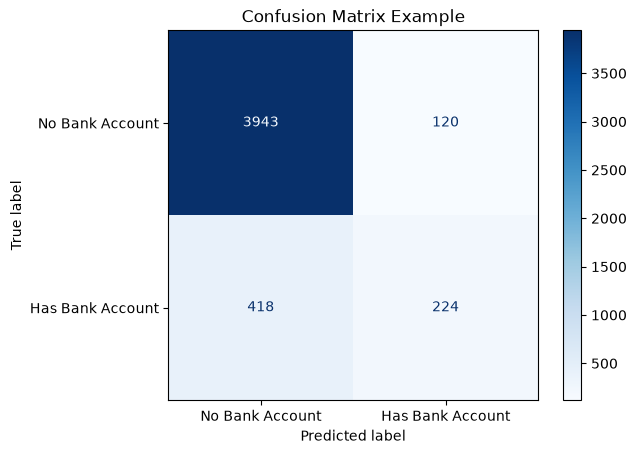

In [27]:
import matplotlib.pyplot as plt
# 2. Compute the confusion matrix counts
cm = confusion_matrix(y_test, y_pred)

labels = ['No Bank Account', 'Has Bank Account']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# 4. Plot using Matplotlib options
disp.plot(cmap=plt.cm.Blues, values_format='d')

# 5. Display the plot
plt.title("Confusion Matrix Example")
plt.show()

In [24]:
!pip install matplotlib

  Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB 330.3 kB/s eta 0:00:22
   --------------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
